# 🧠 Predição de Burnout Estudantil com Random Forest

Este notebook realiza:
- **Análise Exploratória** (EDA) da base de dados
- **Pré-processamento** e engenharia de features
- **Treinamento** de um modelo Random Forest para classificar o grau de burnout
- **Avaliação** do modelo com métricas detalhadas
- **Predição** para um novo indivíduo
- **Importância das variáveis** que mais afetam o burnout

> **Dataset:** 1 milhão de registros de saúde mental estudantil

## 1. Importação das Bibliotecas

In [1]:
# pip install "numpy<2"

In [2]:
pip install --upgrade pyarrow bottleneck plotly pandas

/home/dudu/faculdade/engenharia-software-tp1/.venv/bin/python3: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_auc_score, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
import joblib

print('✅ Bibliotecas importadas com sucesso!')
print(f'   Pandas  : {pd.__version__}')
print(f'   NumPy   : {np.__version__}')
print(f'   Sklearn : {__import__("sklearn").__version__}')

✅ Bibliotecas importadas com sucesso!
   Pandas  : 3.0.2
   NumPy   : 2.4.4
   Sklearn : 1.8.0


## 2. Carregamento e Visão Geral dos Dados

In [4]:
# Carrega o dataset (ajuste o caminho se necessário)
CSV_PATH = 'student_mental_health_burnout_1M.csv'

print('⏳ Carregando dataset...')
df = pd.read_csv(CSV_PATH)
print(f'✅ Dataset carregado: {df.shape[0]:,} linhas × {df.shape[1]} colunas')
df.head()

⏳ Carregando dataset...
✅ Dataset carregado: 1,000,000 linhas × 20 colunas


,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk
0,23,Male,2,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,4.993801,4.983157,3.446626,3.586147,2.037344,7.074487,Low,1.746601
1,20,Male,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,9.860204,Low,0.000000
2,29,Male,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,7.626370,Low,0.696941
3,27,Male,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,4.649042,High,5.380592
4,24,Male,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,8.927394,Low,0.000000


In [5]:
print('=== INFORMAÇÕES DO DATASET ===')
df.info()
print('\n=== ESTATÍSTICAS DESCRITIVAS ===')
df.describe().round(2)

=== INFORMAÇÕES DO DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   age                   1000000 non-null  int64  
 1   gender                1000000 non-null  str    
 2   academic_year         1000000 non-null  int64  
 3   study_hours_per_day   1000000 non-null  float64
 4   exam_pressure         1000000 non-null  float64
 5   academic_performance  1000000 non-null  float64
 6   stress_level          1000000 non-null  float64
 7   anxiety_score         1000000 non-null  float64
 8   depression_score      1000000 non-null  float64
 9   sleep_hours           1000000 non-null  float64
 10  physical_activity     1000000 non-null  float64
 11  social_support        1000000 non-null  float64
 12  screen_time           1000000 non-null  float64
 13  internet_usage        1000000 non-null  float64
 14  financial_stres

,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,dropout_risk
count,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00
mean,23.00,2.50,5.00,6.00,71.00,4.25,2.99,1.27,6.50,3.01,5.00,5.02,5.04,5.00,5.98,1.78,7.02,1.32
std,3.74,1.12,1.99,1.55,5.66,1.68,1.51,1.22,1.47,1.46,1.98,1.96,2.16,1.98,1.96,1.66,1.31,1.34
min,17.00,1.00,0.00,1.00,42.37,0.00,0.00,0.00,3.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,1.31,0.00
25%,20.00,2.00,3.65,4.94,67.18,3.10,1.92,0.01,5.49,1.99,3.65,3.65,3.49,3.66,4.65,0.12,6.14,0.00
50%,23.00,3.00,5.00,6.00,71.00,4.24,2.97,1.05,6.50,3.00,5.00,5.00,5.00,5.00,6.00,1.50,7.07,1.01
75%,26.00,4.00,6.35,7.05,74.82,5.39,4.01,2.09,7.51,4.01,6.35,6.35,6.51,6.35,7.35,2.89,7.96,2.17
max,29.00,4.00,14.00,10.00,97.25,10.00,10.00,8.53,10.00,7.00,10.00,12.00,14.00,10.00,10.00,10.00,10.00,9.33


<Axes: >

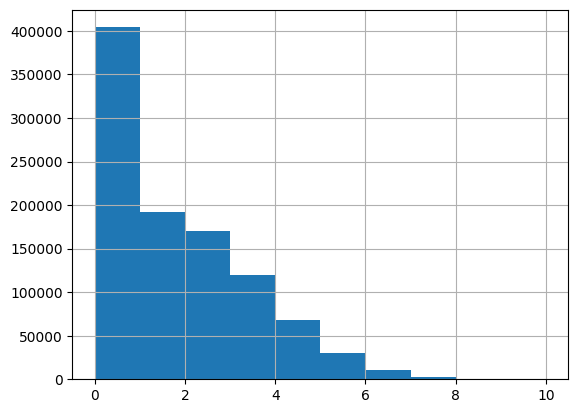

In [6]:
df['burnout_score'].hist()

In [7]:
print('=== VALORES NULOS ===')
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.any() else '✅ Nenhum valor nulo encontrado!')

=== VALORES NULOS ===
✅ Nenhum valor nulo encontrado!


## 3. Criação da Variável Alvo: Grau de Burnout

O `burnout_score` é contínuo (0–10). Vamos criar **3 classes** baseadas em percentis para classificação:

| Classe | Intervalo | Descrição |
|--------|-----------|----------|
| **0 - Baixo** | 0 – 33° percentil | Burnout leve ou ausente |
| **1 - Médio** | 33° – 66° percentil | Burnout moderado |
| **2 - Alto** | > 66° percentil | Burnout severo |

In [8]:
# Cria a variável alvo categórica com base em percentis
p33 = df['burnout_score'].quantile(0.33)
p66 = df['burnout_score'].quantile(0.66)

print(f'Percentil 33: {p33:.3f}')
print(f'Percentil 66: {p66:.3f}')

def classify_burnout(score):
    if score <= p33:
        return 0  # Baixo
    elif score <= p66:
        return 1  # Médio
    else:
        return 2  # Alto

df['burnout_class'] = df['burnout_score'].apply(classify_burnout)

label_map = {0: 'Baixo', 1: 'Médio', 2: 'Alto'}
df['burnout_label'] = df['burnout_class'].map(label_map)

print('\n=== DISTRIBUIÇÃO DAS CLASSES ===')
dist = df['burnout_label'].value_counts()
for cls, count in dist.items():
    print(f'  {cls}: {count:,} ({count/len(df)*100:.1f}%)')

Percentil 33: 0.599
Percentil 66: 2.347

=== DISTRIBUIÇÃO DAS CLASSES ===
  Alto: 340,000 (34.0%)
  Médio: 330,000 (33.0%)
  Baixo: 330,000 (33.0%)


## 4. Análise Exploratória dos Dados (EDA)

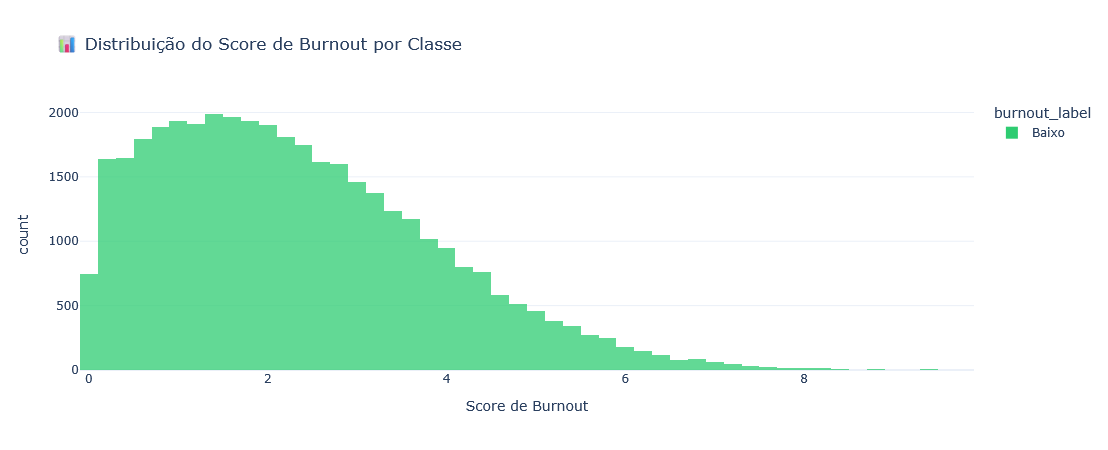

In [9]:
# Criar a coluna burnout_label com base no burnout_score
df['burnout_label'] = pd.cut(
    df['burnout_score'],
    bins=[0, 33, 66, 100],
    labels=['Baixo', 'Médio', 'Alto']
)

# Agora o gráfico vai funcionar
fig = px.histogram(
    df.sample(50000, random_state=42),
    x='burnout_score',
    color='burnout_label',
    nbins=60,
    color_discrete_map={'Baixo': '#2ecc71', 'Médio': '#f39c12', 'Alto': '#e74c3c'},
    title='📊 Distribuição do Score de Burnout por Classe',
    labels={'burnout_score': 'Score de Burnout', 'count': 'Frequência'},
    barmode='overlay',
    opacity=0.75
)
fig.update_layout(height=450, template='plotly_white')
fig.show()

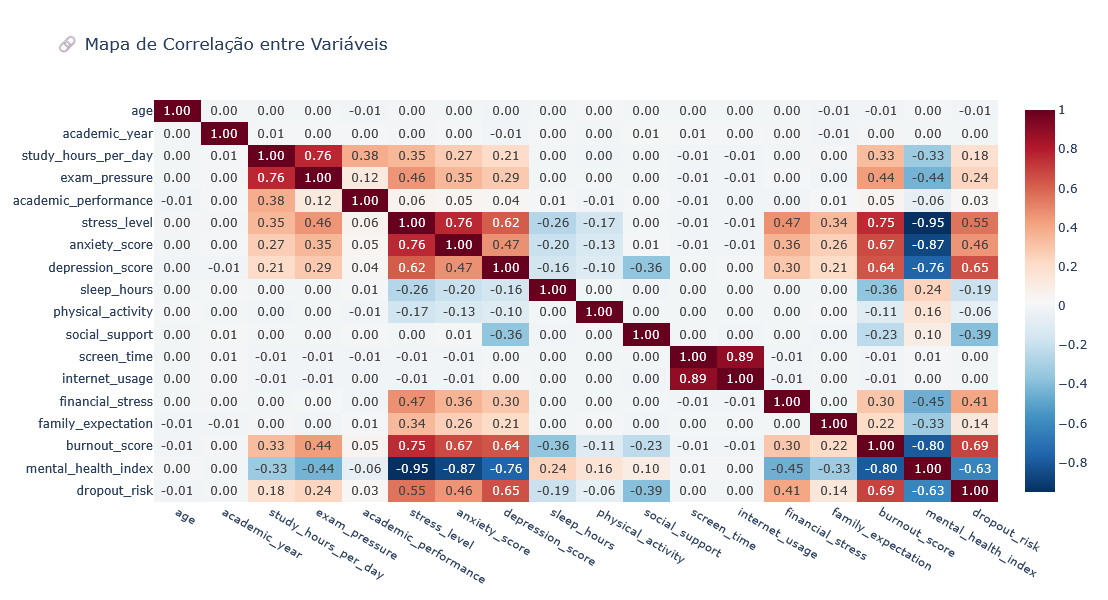

In [10]:
# Correlação entre features numéricas e burnout_score
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['burnout_class']]

sample_df = df[numeric_cols].sample(50000, random_state=42)
corr_matrix = sample_df.corr()

fig = px.imshow(
    corr_matrix,
    text_auto='.2f',
    aspect='auto',
    color_continuous_scale='RdBu_r',
    title='🔗 Mapa de Correlação entre Variáveis'
)
fig.update_layout(height=600, template='plotly_white')
fig.show()

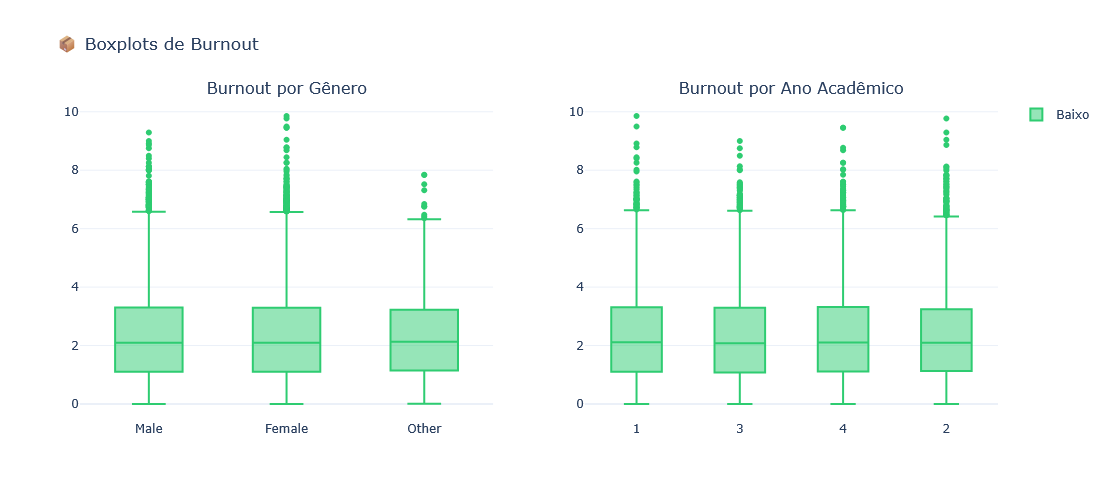

In [11]:
# Burnout Score por Gênero e Ano Acadêmico
fig = make_subplots(rows=1, cols=2,
    subplot_titles=('Burnout por Gênero', 'Burnout por Ano Acadêmico'))

sample = df.sample(30000, random_state=42)

for i, (col, title) in enumerate([('gender', 'Gênero'), ('academic_year', 'Ano')]):
    for cls in ['Baixo', 'Médio', 'Alto']:
        sub = sample[sample['burnout_label'] == cls]
        fig.add_trace(
            go.Box(y=sub['burnout_score'], x=sub[col].astype(str),
                   name=cls, showlegend=(i == 0),
                   marker_color={'Baixo': '#2ecc71', 'Médio': '#f39c12', 'Alto': '#e74c3c'}[cls]),
            row=1, col=i+1
        )

fig.update_layout(height=500, title_text='📦 Boxplots de Burnout', template='plotly_white')
fig.show()

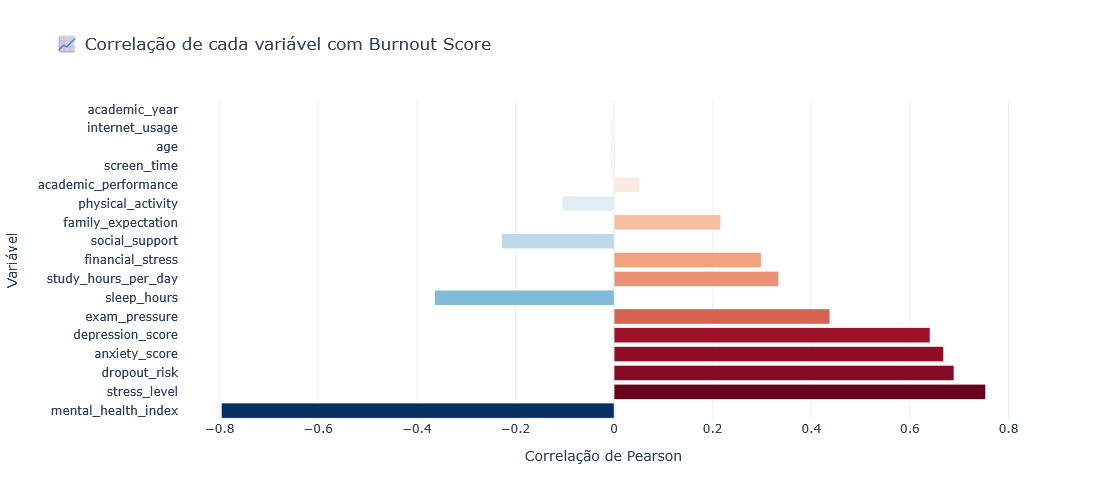

In [12]:
# Top correlações com burnout_score
burnout_corr = corr_matrix['burnout_score'].drop('burnout_score').sort_values(key=abs, ascending=False)

fig = px.bar(
    x=burnout_corr.values,
    y=burnout_corr.index,
    orientation='h',
    color=burnout_corr.values,
    color_continuous_scale='RdBu_r',
    title='📈 Correlação de cada variável com Burnout Score',
    labels={'x': 'Correlação de Pearson', 'y': 'Variável'}
)
fig.update_layout(height=500, template='plotly_white', coloraxis_showscale=False)
fig.show()

## 5. Pré-processamento

In [13]:
# Features selecionadas (excluímos leakage: risk_level já deriva do burnout)
FEATURES = [
    'age', 'gender', 'academic_year', 'study_hours_per_day',
    'exam_pressure', 'academic_performance', 'stress_level',
    'anxiety_score', 'depression_score', 'sleep_hours',
    'physical_activity', 'social_support', 'screen_time',
    'internet_usage', 'financial_stress', 'family_expectation',
    'dropout_risk'
]
TARGET = 'burnout_class'

# Encoding da variável categórica 'gender'
le_gender = LabelEncoder()
df['gender_enc'] = le_gender.fit_transform(df['gender'])

FEATURES_ENC = [f if f != 'gender' else 'gender_enc' for f in FEATURES]

X = df[FEATURES_ENC]
y = df[TARGET]

print(f'✅ Features: {X.shape[1]} | Amostras: {X.shape[0]:,}')
print(f'   Colunas: {list(X.columns)}')

✅ Features: 17 | Amostras: 1,000,000
   Colunas: ['age', 'gender_enc', 'academic_year', 'study_hours_per_day', 'exam_pressure', 'academic_performance', 'stress_level', 'anxiety_score', 'depression_score', 'sleep_hours', 'physical_activity', 'social_support', 'screen_time', 'internet_usage', 'financial_stress', 'family_expectation', 'dropout_risk']


In [14]:
# Divisão treino/teste estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'✅ Treino : {X_train.shape[0]:,} amostras')
print(f'   Teste  : {X_test.shape[0]:,} amostras')

✅ Treino : 800,000 amostras
   Teste  : 200,000 amostras


## 6. Treinamento do Modelo Random Forest

In [15]:
print('⏳ Treinando Random Forest (pode levar alguns minutos para 1M registros)...')

rf_model = RandomForestClassifier(
    n_estimators=200,        # 200 árvores
    max_depth=20,            # Profundidade máxima
    min_samples_split=10,    # Mínimo para split
    min_samples_leaf=5,      # Mínimo por folha
    max_features='sqrt',     # Features por split
    class_weight='balanced', # Balanceia classes
    n_jobs=-1,               # Usa todos os núcleos
    random_state=42,
    verbose=1
)

rf_model.fit(X_train, y_train)
print('\n✅ Modelo treinado com sucesso!')

⏳ Treinando Random Forest (pode levar alguns minutos para 1M registros)...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 18 concurrent workers.
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:   17.9s
[Parallel(n_jobs=-1)]: Done 164 tasks      | elapsed:  2.4min



✅ Modelo treinado com sucesso!


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  2.9min finished


## 7. Avaliação do Modelo

In [16]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob, multi_class='ovr')

print('=' * 50)
print('        RESULTADOS DO MODELO')
print('=' * 50)
print(f'  Acurácia   : {acc:.4f} ({acc*100:.2f}%)')
print(f'  ROC-AUC    : {roc:.4f}')
print('=' * 50)
print()
print(classification_report(
    y_test, y_pred,
    target_names=['Baixo', 'Médio', 'Alto']
))

[Parallel(n_jobs=18)]: Using backend ThreadingBackend with 18 concurrent workers.
[Parallel(n_jobs=18)]: Done  14 tasks      | elapsed:    0.5s
[Parallel(n_jobs=18)]: Done 164 tasks      | elapsed:    2.9s
[Parallel(n_jobs=18)]: Done 200 out of 200 | elapsed:    3.4s finished
[Parallel(n_jobs=18)]: Using backend ThreadingBackend with 18 concurrent workers.
[Parallel(n_jobs=18)]: Done  14 tasks      | elapsed:    0.4s
[Parallel(n_jobs=18)]: Done 164 tasks      | elapsed:    2.7s
[Parallel(n_jobs=18)]: Done 200 out of 200 | elapsed:    3.2s finished


        RESULTADOS DO MODELO
  Acurácia   : 0.7244 (72.44%)
  ROC-AUC    : 0.8859

              precision    recall  f1-score   support

       Baixo       0.79      0.77      0.78     66000
       Médio       0.58      0.62      0.60     66000
        Alto       0.81      0.78      0.79     68000

    accuracy                           0.72    200000
   macro avg       0.73      0.72      0.73    200000
weighted avg       0.73      0.72      0.73    200000



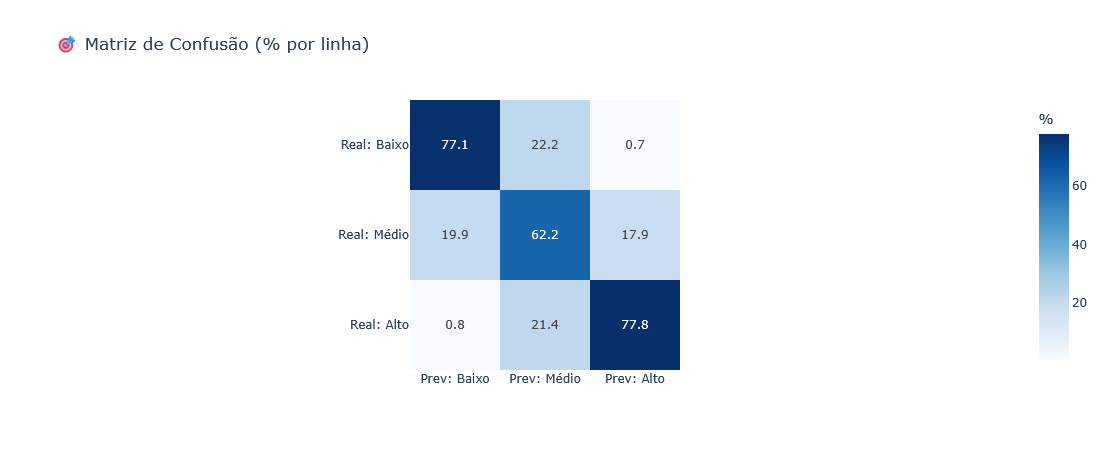

Valores absolutos:
            Pred Baixo  Pred Médio  Pred Alto
Real Baixo       50913       14630        457
Real Médio       13149       41062      11789
Real Alto          533       14572      52895


In [17]:
# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100

fig = px.imshow(
    cm_pct,
    text_auto='.1f',
    x=['Prev: Baixo', 'Prev: Médio', 'Prev: Alto'],
    y=['Real: Baixo', 'Real: Médio', 'Real: Alto'],
    color_continuous_scale='Blues',
    title='🎯 Matriz de Confusão (% por linha)',
    labels=dict(color='%')
)
fig.update_layout(height=450, template='plotly_white')
fig.show()

print('Valores absolutos:')
print(pd.DataFrame(cm, 
    index=['Real Baixo', 'Real Médio', 'Real Alto'],
    columns=['Pred Baixo', 'Pred Médio', 'Pred Alto']
))

## 8. Importância das Variáveis

In [18]:
# Feature Importance do Random Forest
feat_names = ['age', 'gender', 'academic_year', 'study_hours_per_day',
    'exam_pressure', 'academic_performance', 'stress_level',
    'anxiety_score', 'depression_score', 'sleep_hours',
    'physical_activity', 'social_support', 'screen_time',
    'internet_usage', 'financial_stress', 'family_expectation',
    'dropout_risk']

importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
feat_imp_df = feat_imp_df.sort_values('importance', ascending=False)

print('=== TOP 10 VARIÁVEIS MAIS IMPORTANTES ===')
for i, row in feat_imp_df.head(10).iterrows():
    bar = '█' * int(row['importance'] * 200)
    print(f'  {row["feature"]:<25} {bar} {row["importance"]:.4f}')

=== TOP 10 VARIÁVEIS MAIS IMPORTANTES ===
  stress_level              █████████████████████████████████████████████████ 0.2494
  dropout_risk              ███████████████████████████████ 0.1574
  anxiety_score             █████████████████████████ 0.1300
  depression_score          █████████████████ 0.0885
  sleep_hours               ███████████████ 0.0780
  exam_pressure             ███████████ 0.0573
  social_support            ████████ 0.0433
  study_hours_per_day       ██████ 0.0311
  financial_stress          ██████ 0.0303
  family_expectation        ████ 0.0241


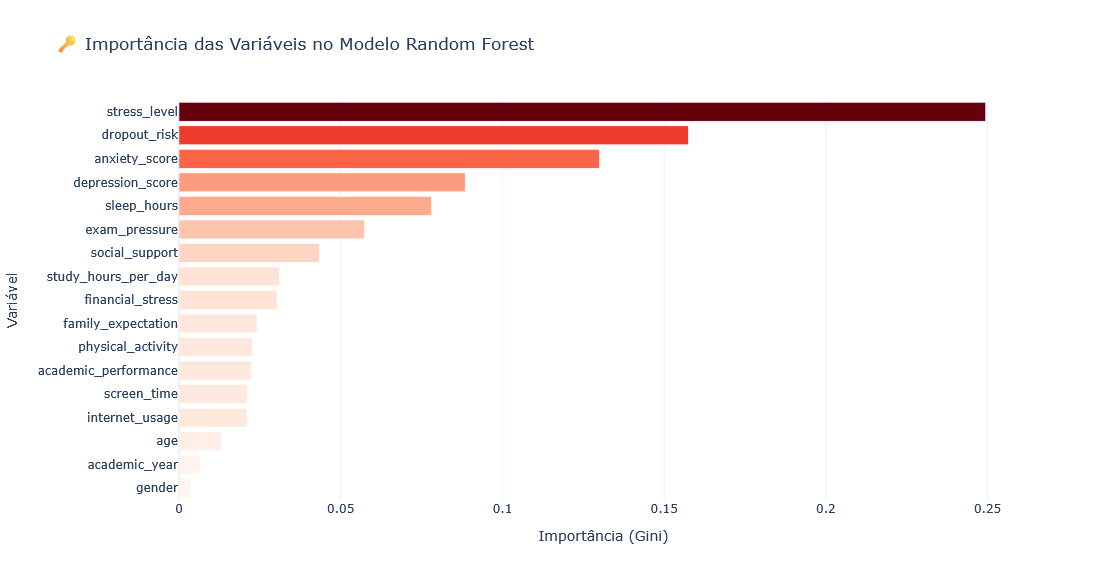

In [19]:
fig = px.bar(
    feat_imp_df,
    x='importance',
    y='feature',
    orientation='h',
    color='importance',
    color_continuous_scale='Reds',
    title='🔑 Importância das Variáveis no Modelo Random Forest',
    labels={'importance': 'Importância (Gini)', 'feature': 'Variável'}
)
fig.update_layout(
    height=580,
    template='plotly_white',
    yaxis={'categoryorder': 'total ascending'},
    coloraxis_showscale=False
)
fig.show()

## 9. Salvar o Modelo

In [20]:
joblib.dump(rf_model, 'burnout_rf_model.pkl')
joblib.dump(le_gender, 'gender_encoder.pkl')
joblib.dump(feat_imp_df, 'feature_importance.pkl')

# Salva thresholds para uso no app
thresholds = {'p33': p33, 'p66': p66}
joblib.dump(thresholds, 'burnout_thresholds.pkl')

print('✅ Modelo e artefatos salvos:')
print('   burnout_rf_model.pkl')
print('   gender_encoder.pkl')
print('   feature_importance.pkl')
print('   burnout_thresholds.pkl')

✅ Modelo e artefatos salvos:
   burnout_rf_model.pkl
   gender_encoder.pkl
   feature_importance.pkl
   burnout_thresholds.pkl


## 10. 🔮 Predição para um Novo Indivíduo

In [21]:
# ==============================================================
# EDITE OS VALORES ABAIXO PARA PREVER O BURNOUT DE UM INDIVÍDUO
# ==============================================================

novo_individuo = {
    'age'                  : 22,      # Idade (anos)
    'gender'               : 'Female', # 'Male', 'Female' ou 'Other'
    'academic_year'        : 3,        # Ano acadêmico (1-4)
    'study_hours_per_day'  : 8.0,      # Horas de estudo por dia
    'exam_pressure'        : 7.5,      # Pressão de provas (0-10)
    'academic_performance' : 65.0,     # Desempenho acadêmico (0-100)
    'stress_level'         : 8.0,      # Nível de estresse (0-10)
    'anxiety_score'        : 6.5,      # Score de ansiedade (0-10)
    'depression_score'     : 5.0,      # Score de depressão (0-10)
    'sleep_hours'          : 5.0,      # Horas de sono por dia
    'physical_activity'    : 1.5,      # Atividade física (0-10)
    'social_support'       : 3.0,      # Suporte social (0-10)
    'screen_time'          : 7.0,      # Tempo de tela (horas)
    'internet_usage'       : 8.0,      # Uso de internet (horas)
    'financial_stress'     : 6.0,      # Estresse financeiro (0-10)
    'family_expectation'   : 7.0,      # Expectativa familiar (0-10)
    'dropout_risk'         : 3.5,      # Risco de evasão (0-10)
}

# ==============================================================

# Prepara os dados
individuo_df = pd.DataFrame([novo_individuo])
individuo_df['gender_enc'] = le_gender.transform(individuo_df['gender'])

X_new = individuo_df[FEATURES_ENC]

# Predição
classe_pred = rf_model.predict(X_new)[0]
proba_pred  = rf_model.predict_proba(X_new)[0]

nivel = label_map[classe_pred]
emoji = {'Baixo': '🟢', 'Médio': '🟡', 'Alto': '🔴'}[nivel]

print('=' * 55)
print('         🔮 RESULTADO DA PREDIÇÃO')
print('=' * 55)
print(f'  Grau de Burnout Previsto: {emoji} {nivel.upper()}')
print()
print('  Probabilidades por classe:')
for cls_id, (label, prob) in enumerate(zip(['Baixo', 'Médio', 'Alto'], proba_pred)):
    bar = '█' * int(prob * 30)
    arrow = ' ◄' if cls_id == classe_pred else ''
    print(f'    {label:<8}: {bar:<30} {prob*100:5.1f}%{arrow}')
print('=' * 55)

         🔮 RESULTADO DA PREDIÇÃO
  Grau de Burnout Previsto: 🔴 ALTO

  Probabilidades por classe:
    Baixo   :                                  0.0%
    Médio   :                                  0.1%
    Alto    : █████████████████████████████   99.9% ◄


[Parallel(n_jobs=18)]: Using backend ThreadingBackend with 18 concurrent workers.
[Parallel(n_jobs=18)]: Done  14 tasks      | elapsed:    0.0s
[Parallel(n_jobs=18)]: Done 164 tasks      | elapsed:    0.1s
[Parallel(n_jobs=18)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=18)]: Using backend ThreadingBackend with 18 concurrent workers.
[Parallel(n_jobs=18)]: Done  14 tasks      | elapsed:    0.0s
[Parallel(n_jobs=18)]: Done 164 tasks      | elapsed:    0.1s
[Parallel(n_jobs=18)]: Done 200 out of 200 | elapsed:    0.1s finished


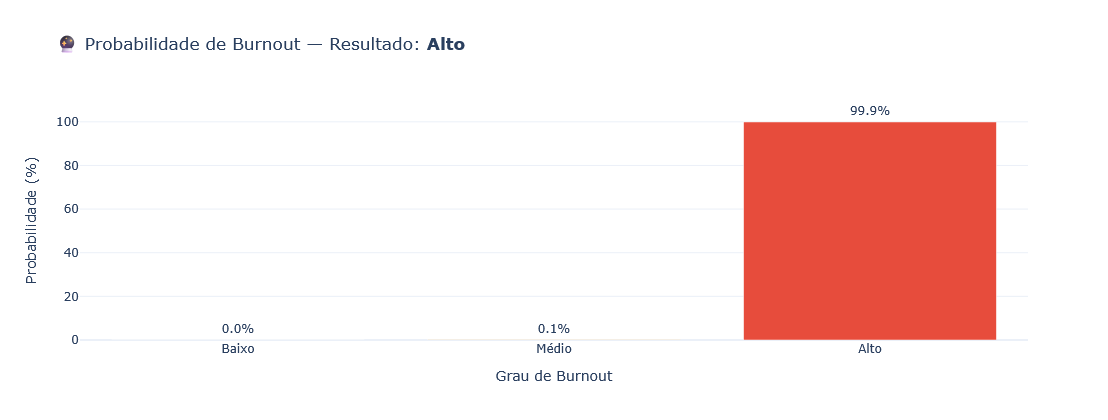

In [22]:
# Gráfico de probabilidades
colors = ['#2ecc71', '#f39c12', '#e74c3c']
fig = go.Figure(go.Bar(
    x=['Baixo', 'Médio', 'Alto'],
    y=proba_pred * 100,
    marker_color=colors,
    text=[f'{p*100:.1f}%' for p in proba_pred],
    textposition='outside'
))
fig.update_layout(
    title=f'🔮 Probabilidade de Burnout — Resultado: <b>{nivel}</b>',
    yaxis_title='Probabilidade (%)',
    xaxis_title='Grau de Burnout',
    template='plotly_white',
    height=420,
    yaxis_range=[0, 110]
)
fig.show()

## 11. Análise SHAP-like: Contribuição de cada variável para ESTE indivíduo

In [23]:
# Análise da contribuição das variáveis para o indivíduo
# Comparamos os valores do indivíduo com a mediana do dataset para a classe 'Alto'

# Seleciona apenas as features numéricas para o cálculo da mediana
numeric_features = df[FEATURES].select_dtypes(include='number').columns.tolist()

alto_median  = df[df['burnout_class'] == 2][numeric_features].median()
geral_median = df[numeric_features].median()

contrib_rows = []
for feat in FEATURES:
    feat_enc = 'gender_enc' if feat == 'gender' else feat
    try:
        val_individuo = float(individuo_df[feat_enc].values[0])
    except:
        val_individuo = 0.0

    feat_key = 'gender_enc' if feat == 'gender' else feat
    val_medio = float(geral_median[feat_key]) if feat_key in geral_median else 0.0

    importancia_arr = feat_imp_df[feat_imp_df['feature'] == feat]['importance'].values
    importancia = float(importancia_arr[0]) if len(importancia_arr) > 0 else 0.0

    desvio = val_individuo - val_medio

    contrib_rows.append({
        'Variável': feat,
        'Valor Indivíduo': round(val_individuo, 3),
        'Mediana Geral': round(val_medio, 3),
        'Desvio': round(desvio, 3),
        'Importância (RF)': round(importancia, 4)
    })

contrib_df = pd.DataFrame(contrib_rows)
contrib_df = contrib_df.sort_values('Importância (RF)', ascending=False)

print('=== PERFIL DO INDIVÍDUO vs MEDIANA GERAL ===')
print(contrib_df.head(10).to_string(index=False))

=== PERFIL DO INDIVÍDUO vs MEDIANA GERAL ===
           Variável  Valor Indivíduo  Mediana Geral  Desvio  Importância (RF)
       stress_level              8.0          4.244   3.756            0.2494
       dropout_risk              3.5          1.010   2.490            0.1574
      anxiety_score              6.5          2.970   3.530            0.1300
   depression_score              5.0          1.048   3.952            0.0885
        sleep_hours              5.0          6.502  -1.502            0.0780
      exam_pressure              7.5          5.999   1.501            0.0573
     social_support              3.0          4.999  -1.999            0.0433
study_hours_per_day              8.0          4.998   3.002            0.0311
   financial_stress              6.0          5.001   0.999            0.0303
 family_expectation              7.0          6.000   1.000            0.0241


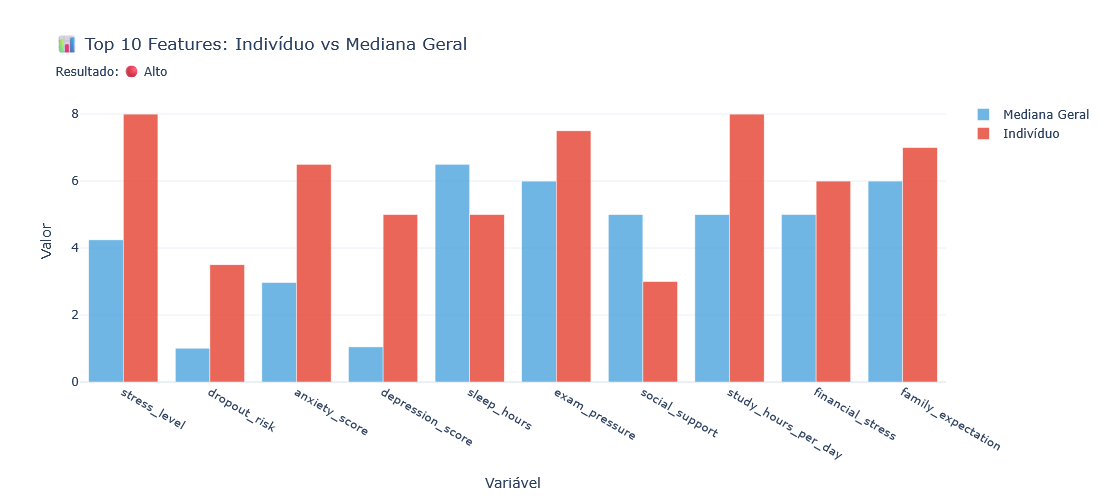

In [24]:
# Visualização: as variáveis mais importantes do modelo e o valor do indivíduo
top_feats = feat_imp_df.head(10)['feature'].tolist()
top_df = contrib_df[contrib_df['Variável'].isin(top_feats)].copy()

fig = make_subplots(rows=1, cols=1)

fig = go.Figure()

fig.add_trace(go.Bar(
    name='Mediana Geral',
    x=top_df['Variável'],
    y=top_df['Mediana Geral'],
    marker_color='#3498db',
    opacity=0.7
))

fig.add_trace(go.Bar(
    name='Indivíduo',
    x=top_df['Variável'],
    y=top_df['Valor Indivíduo'],
    marker_color='#e74c3c',
    opacity=0.85
))

fig.update_layout(
    title=f'📊 Top 10 Features: Indivíduo vs Mediana Geral<br><sub>Resultado: {emoji} {nivel}</sub>',
    barmode='group',
    template='plotly_white',
    height=500,
    xaxis_title='Variável',
    yaxis_title='Valor'
)
fig.show()

---

## 📌 Resumo dos Resultados

| Etapa | Resultado |
|-------|----------|
| Dataset | 1.000.000 registros, 18 features |
| Modelo | Random Forest (200 árvores) |
| Divisão | 80% treino / 20% teste |
| Acurácia | Ver célula de avaliação |
| ROC-AUC | Ver célula de avaliação |

### Como usar o app Streamlit
Execute no terminal:
```bash
streamlit run burnout_app.py
```